In [30]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [31]:
df = pd.read_csv("online_retail.csv")

In [32]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [33]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [34]:
df.shape

(541909, 8)

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [36]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [37]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [38]:
df.dropna(subset=["CustomerID","Description"],inplace=True)

In [39]:
df.duplicated().sum()

np.int64(5225)

In [40]:
df = df.drop_duplicates()

In [41]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [42]:
df = df[df["Quantity"] > 0]

In [43]:
df = df[df["UnitPrice"] > 0]

In [44]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [45]:
df["Total_Price"] = df["Quantity"] * df["UnitPrice"]

In [46]:
df["Month"] = df["InvoiceDate"].dt.month

In [47]:
df["Year"] = df["InvoiceDate"].dt.year

In [48]:
df.columns = df.columns.str.lower()

In [49]:
df.shape

(392692, 11)

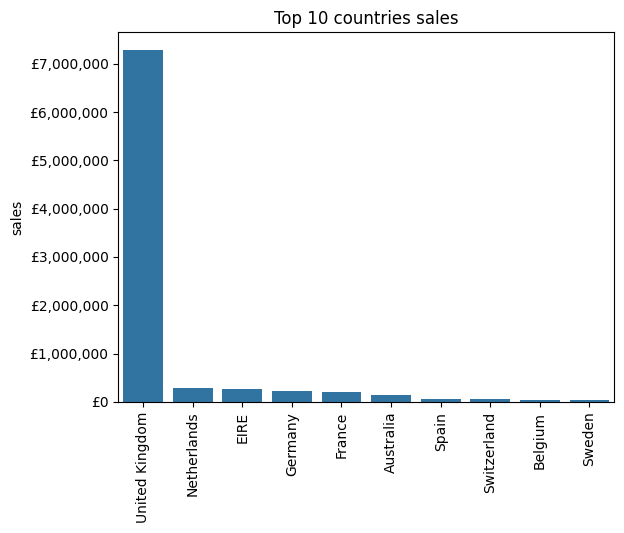

In [59]:
top_countries_sales = df.groupby("country")["total_price"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries_sales.index,y=top_countries_sales.values)
plt.xticks(rotation=90)
plt.title("Top 10 countries sales")
plt.ylabel("sales")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xlabel(None)
plt.show()

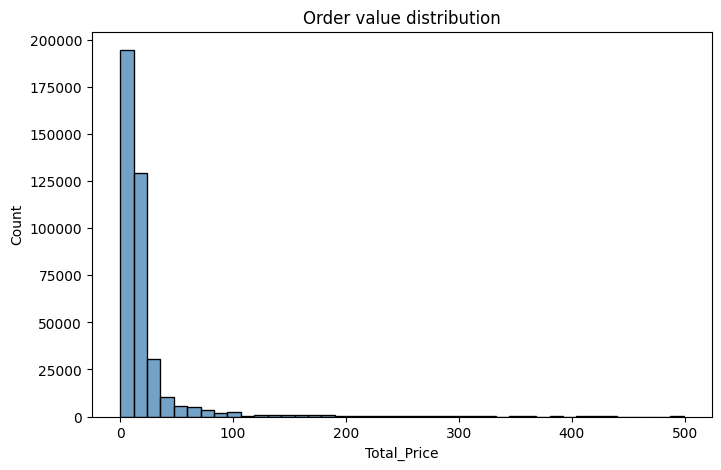

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(df[df["total_price"] < 500]["total_price"],bins=50,binwidth=12,color='steelblue',stat="count")
plt.xlabel("Total_Price")
plt.ylabel("Count")
plt.title("Order value distribution")
plt.show()

In [52]:
monthly_sales = df.groupby(["year","month"])["total_price"].sum().reset_index()

In [53]:
monthly_sales["periods"] = monthly_sales["year"].astype(str) + "-" + monthly_sales["month"].astype(str)

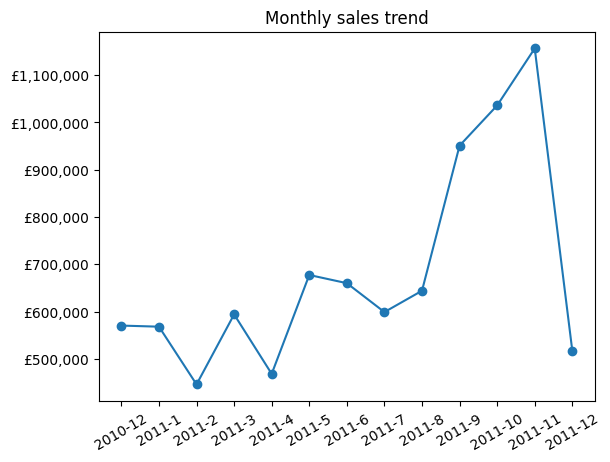

In [54]:
plt.plot(monthly_sales["periods"],monthly_sales["total_price"],marker="o")
plt.xticks(rotation=30)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.title("Monthly sales trend")
plt.show()

In [56]:
cor = df[["quantity","unitprice","total_price"]].corr()

<Axes: >

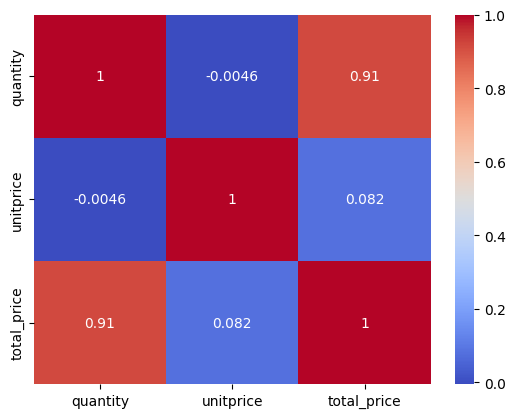

In [57]:
sns.heatmap(cor,annot=True,cmap="coolwarm")